Linear Kernel Metrics:
Accuracy: 0.9000
Precision: 0.9014
Recall: 0.9000


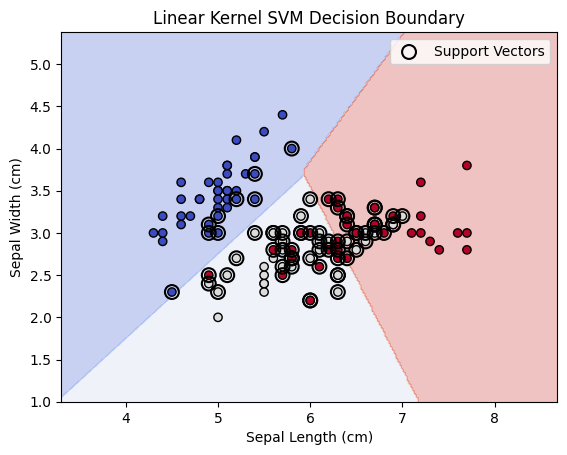


RBF Kernel Metrics:
Accuracy: 0.9000
Precision: 0.9014
Recall: 0.9000


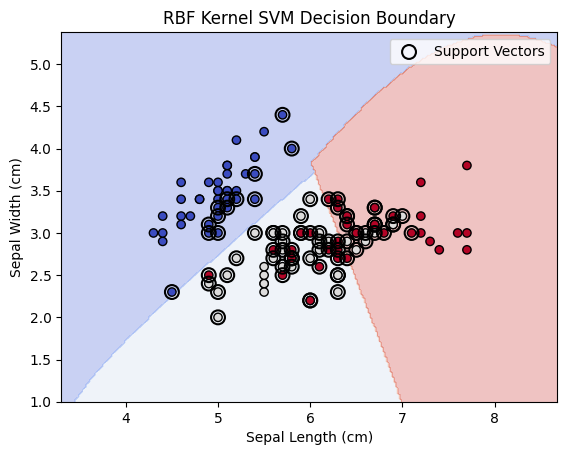

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load Iris dataset and select first two features
iris = load_iris()
X = iris.data[:, :2]  # Sepal length and width
y = iris.target  # Multi-class labels

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to plot decision boundary and support vectors
def plot_decision_boundary(X, y, model, title):
    h = 0.02  # Step size in mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predict on mesh points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and points
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    
    # Highlight support vectors
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], 
                s=100, facecolors='none', edgecolors='black', linewidths=1.5, label='Support Vectors')
    
    plt.xlabel('Sepal Length (cm)')
    plt.ylabel('Sepal Width (cm)')
    plt.title(title)
    plt.legend()
    plt.show()

# Train and evaluate SVM with linear kernel
linear_svm = SVC(kernel='linear', random_state=42)
linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)
linear_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_linear),
    'Precision': precision_score(y_test, y_pred_linear, average='weighted'),
    'Recall': recall_score(y_test, y_pred_linear, average='weighted')
}
print("Linear Kernel Metrics:")
for metric, value in linear_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot decision boundary for linear kernel
plot_decision_boundary(X_train, y_train, linear_svm, 'Linear Kernel SVM Decision Boundary')

# Train and evaluate SVM with RBF kernel
rbf_svm = SVC(kernel='rbf', random_state=42)
rbf_svm.fit(X_train, y_train)
y_pred_rbf = rbf_svm.predict(X_test)
rbf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rbf),
    'Precision': precision_score(y_test, y_pred_rbf, average='weighted'),
    'Recall': recall_score(y_test, y_pred_rbf, average='weighted')
}
print("\nRBF Kernel Metrics:")
for metric, value in rbf_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot decision boundary for RBF kernel
plot_decision_boundary(X_train, y_train, rbf_svm, 'RBF Kernel SVM Decision Boundary')